In [1]:
# Import libraries
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

import requests
import scipy.stats as stats

import textwrap

import torch
import torch.nn as nn
import torch.nn.functional as F

from transformers import AutoTokenizer, AutoModelForCausalLM, logging

logging.set_verbosity_error()

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
# Eleuther's tokenizer
tokenizer = AutoTokenizer.from_pretrained('EleutherAI/gpt-neo-125m')
tokenizer.pad_token_id = tokenizer.encode(' ')[0]

# load in GPTneo
model = AutoModelForCausalLM.from_pretrained('EleutherAI/gpt-neo-125m').to(device)
model.eval()

embed_dim = model.config.hidden_size

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/357 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/526M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/160 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

# Get nouns

In [4]:
# list of nouns
url = 'https://raw.githubusercontent.com/david47k/top-english-wordlists/refs/heads/master/top_english_nouns_lower_10000.txt'
nouns = requests.get(url).text
nouns = nouns.split('\n')[:100]

# Implant hook

In [23]:
layer2hook = 8
hook_name = f'mlp_{layer2hook}_c_fc'
activations = {}

num_neurons = model.transformer.h[layer2hook].mlp.c_fc.weight.shape[0]

if hook_handle is not None: hook_handle.remove()

hook_handle = model.transformer.h[layer2hook].mlp.c_fc.register_forward_hook(lambda module, input, output: activations.__setitem__(hook_name, output.detach()))

In [21]:
# Test the hook function
text = "This is a code written in Python"
token_ids = tokenizer.encode(text, return_tensors='pt').to(device)

with torch.no_grad(): model(token_ids)

activations[hook_name].shape



torch.Size([1, 7, 3072])

In [13]:
# Get activations for all nouns with and without space
activation_array = np.zeros((2, len(nouns), num_neurons))
for i in range(len(nouns)):

  # activations without space
  token_ids = tokenizer.encode(nouns[i], return_tensors='pt').to(device)
  with torch.no_grad(): model(token_ids)

  activation_array[0,i,:] = activations[hook_name].mean(dim=1).squeeze().detach().cpu().numpy()

  # activations with space
  token_ids = tokenizer.encode(' ' + nouns[i], return_tensors='pt').to(device)
  with torch.no_grad(): model(token_ids)

  activation_array[1,i,:] = activations[hook_name].mean(dim=1).squeeze().detach().cpu().numpy()

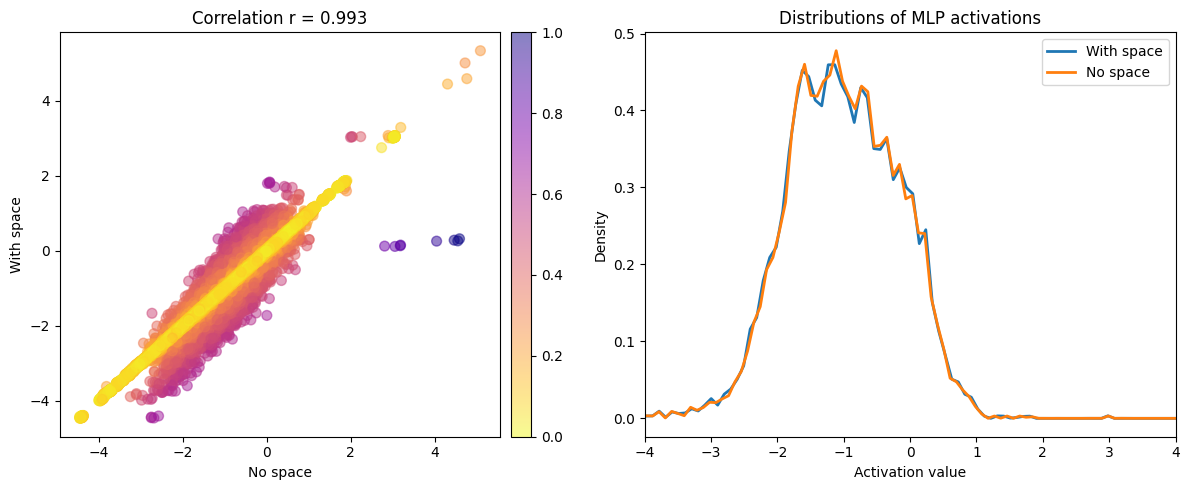

In [19]:
# convenience variables
noSpace  = activation_array[0,:,:].flatten()
yesSpace = activation_array[1,:,:].flatten()

# square root of distances
diffs = np.sqrt(abs(noSpace-yesSpace))
diffs /= diffs.max()


# scatter plots
_,axs = plt.subplots(1,2,figsize=(12,5))
im = axs[0].scatter(noSpace,yesSpace,s=50,c=diffs,alpha=.5,cmap=mpl.cm.plasma_r)
axs[0].set(xlabel='No space',ylabel='With space',
              title=f'Correlation r = {np.corrcoef(noSpace,yesSpace)[0,1]:.3f}')
plt.colorbar(im,ax=axs[0],pad=.02)


# histograms
y_yes,x_yes = np.histogram(yesSpace,bins=100,density=True)
y_noS,x_noS = np.histogram(noSpace,bins=100,density=True)

axs[1].plot(x_yes[:-1],y_yes,linewidth=2,label='With space')
axs[1].plot(x_noS[:-1],y_noS,linewidth=2,label='No space')

axs[1].legend()
axs[1].set(xlim=[-4,4],xlabel='Activation value',ylabel='Density',title='Distributions of MLP activations')

plt.tight_layout()
plt.show()

# Activations from generated tokens

In [35]:
seed_text = "I think the world could be better if"
token_ids = tokenizer(seed_text, return_tensors='pt')['input_ids'].to(device)

# Generate 200 tokens from the seed_text
generated_token_ids = model.generate(inputs=token_ids,
               do_sample=True,
               min_length=200,
               max_length=200
)

generated_text = tokenizer.decode(generated_token_ids[0])

print("Generated text:")
print(textwrap.fill(generated_text, width=70))

Generated text:
I think the world could be better if we don’t have the money for
things to come, we could give the government that much money (like
they did with the Iraq War) while the taxpayers would get the tax
payout and the people who run the government. There is plenty of work
to be done, but more needs to be done and done, and by then it is
already too late. We really shouldn’t pay that.  Forgive my ignorance,
but one of the great myths of the past 30 years of American history
has to be true. No country has ever been so good as Great Britain. No
country has ever been so good as Great Britain has never had the
opportunity to go back to Europe. We have the technology, the
resources, the knowledge, and we have the skills, it has never been
this bad. That is how Britain developed and we should all have the
chance to come back to the United States as well as Europe. Because of


In [37]:
# Push the tokens through the model
with torch.no_grad(): model(generated_token_ids)

fulltext_activations = activations[hook_name]

In [42]:
fulltext_activations[0].shape

torch.Size([200, 3072])

In [45]:
activations_array = np.zeros((2,num_neurons, len(generated_token_ids[0])))

for itok, tok in enumerate(generated_token_ids[0]):

  # forward pass individual tokens
  with torch.no_grad(): model(tok.unsqueeze(0).unsqueeze(0).to(device))
  activations_array[0, :, itok] = activations[hook_name][0,0,:].numpy()
  activations_array[1,:,itok] = fulltext_activations[0,itok,:].numpy()

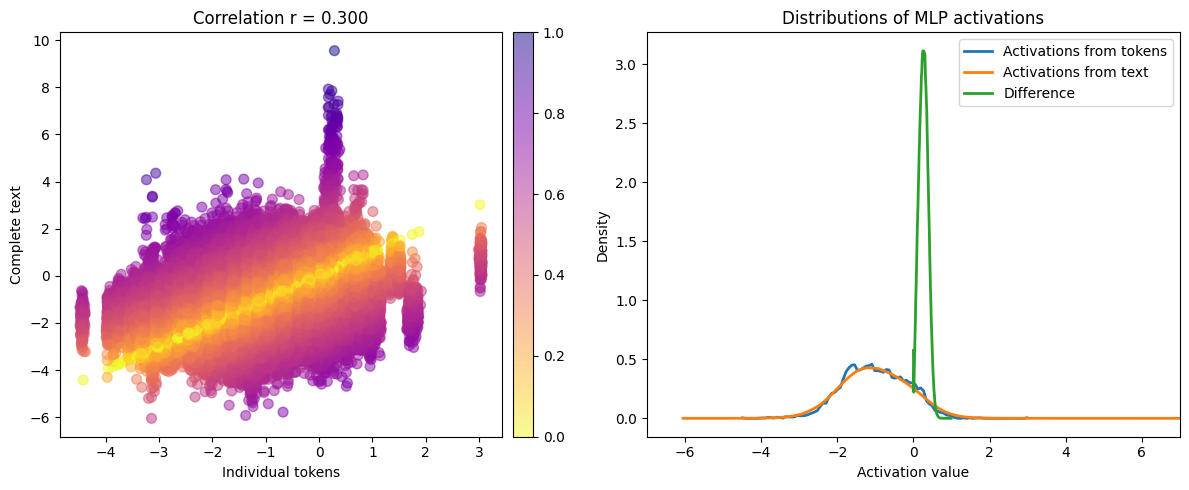

In [53]:
# convenience variables (IMPORTANT: activations_array, not activation_array)
from_tokens = activations_array[0, :, :].ravel()
from_text   = activations_array[1, :, :].ravel()

# distance-like measure for coloring
diffs = np.sqrt(np.abs(from_tokens - from_text))
mx = diffs.max()
if mx > 0:
    diffs /= mx

# scatter plots
_, axs = plt.subplots(1, 2, figsize=(12, 5))

im = axs[0].scatter(
    from_tokens, from_text,
    s=50, c=diffs, alpha=0.5,
    cmap=mpl.cm.plasma_r
)

r = np.corrcoef(from_tokens, from_text)[0, 1]
axs[0].set(
    xlabel="Individual tokens",
    ylabel="Complete text",
    title=f"Correlation r = {r:.3f}"
)
plt.colorbar(im, ax=axs[0], pad=0.02)

# histograms
y_tok, x_tok   = np.histogram(from_tokens, bins=100, density=True)
y_text, x_text = np.histogram(from_text,   bins=100, density=True)
y_diff, x_diff = np.histogram(diffs,       bins=100, density=True)

axs[1].plot(x_tok[:-1],  y_tok,  linewidth=2, label="Activations from tokens")
axs[1].plot(x_text[:-1], y_text, linewidth=2, label="Activations from text")
axs[1].plot(x_diff[:-1], y_diff, linewidth=2, label="Difference")

axs[1].legend()
axs[1].set(
    xlim=[-7, 7],
    xlabel="Activation value",
    ylabel="Density",
    title="Distributions of MLP activations"
)

plt.tight_layout()
plt.show()
